# Baseline Model — Logistic Regression

This notebook trains a baseline logistic regression model to predict in-hospital mortality from first-24-hour ICU features. The goal is to establish a performance floor against which more complex models can be compared.

## Pipeline

The model is wrapped in a scikit-learn `Pipeline` with three steps:

1. **Median imputation** for missing values in numeric features
2. **Standardization** (zero mean, unit variance) for numeric features
3. **Logistic regression** with L2 regularization

Categorical features (ICU type, region, etc.) are dropped from the baseline since logistic regression with one-hot encoding adds many features without strong predictive value at this stage. They will be incorporated in the LightGBM model.

## Evaluation

Performance is reported using:
- **ROC-AUC** — overall discrimination
- **PR-AUC** (average precision) — performance on the rare positive class (8.3% mortality)
- **Calibration plot** — whether predicted probabilities match actual mortality rates
- **Confusion matrix** at the optimal Youden's J threshold

Train/test split is stratified by mortality outcome, 80/20 ratio.

## Import Libraries

In [9]:
import joblib
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.calibration import calibration_curve
from sklearn.metrics import f1_score
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    roc_auc_score, average_precision_score, roc_curve, precision_recall_curve,
    confusion_matrix, classification_report,
)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 11

print("Imports loaded.")

Imports loaded.


## Load features and split into train/test

In [2]:
# Load the feature DataFrame from the parquet file
features = pd.read_parquet("../data/features_final.parquet")
print(f"Loaded features: {features.shape}")
print(f"Mortality rate: {features['in_hospital_mortality'].mean()*100:.2f}%")

# Identify columns
target_col = "in_hospital_mortality"
id_col = "patientunitstayid"

# Drop categorical columns for the baseline
# (will be added back in LightGBM with native categorical handling)
categorical_cols = ["unittype", "numbedscategory", "region"]
drop_cols = [id_col, target_col] + categorical_cols

# Numeric features only
feature_cols = [c for c in features.columns if c not in drop_cols]
print(f"\nUsing {len(feature_cols)} numeric features")

X = features[feature_cols]
y = features[target_col]

# Train/test split, stratified to preserve mortality rate in both
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTrain set: {X_train.shape[0]} patients, {y_train.sum()} deaths ({y_train.mean()*100:.2f}%)")
print(f"Test set:  {X_test.shape[0]} patients, {y_test.sum()} deaths ({y_test.mean()*100:.2f}%)")

Loaded features: (1424, 102)
Mortality rate: 8.29%

Using 97 numeric features

Train set: 1139 patients, 94 deaths (8.25%)
Test set:  285 patients, 24 deaths (8.42%)


## Build pipeline and train

In [3]:
# Build the modeling pipeline
pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        penalty="l2",
        C=1.0,
        max_iter=1000,
        random_state=42,
    )),
])

# Train
pipeline.fit(X_train, y_train)

# Predict probabilities on test set
y_pred_proba = pipeline.predict_proba(X_test)[:, 1]

# Compute metrics
roc_auc = roc_auc_score(y_test, y_pred_proba)
pr_auc = average_precision_score(y_test, y_pred_proba)

print(f"Test ROC-AUC: {roc_auc:.3f}")
print(f"Test PR-AUC:  {pr_auc:.3f}")
print(f"Baseline PR-AUC (predicting prevalence): {y_test.mean():.3f}")

Test ROC-AUC: 0.845
Test PR-AUC:  0.257
Baseline PR-AUC (predicting prevalence): 0.084


/opt/anaconda3/envs/eicu/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


## ROC and PR curves

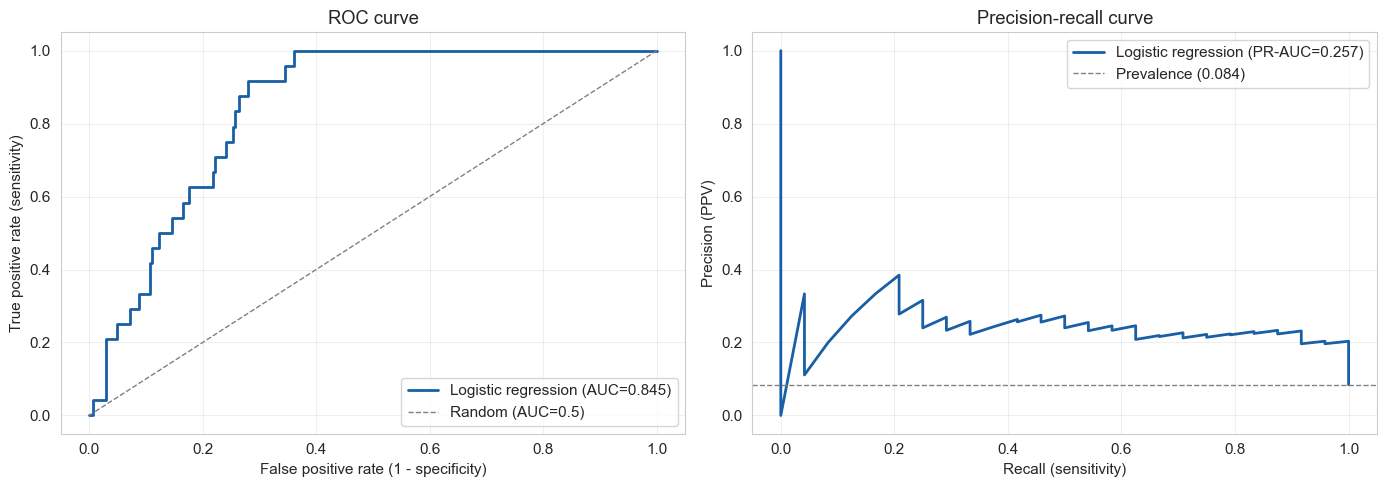

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
axes[0].plot(fpr, tpr, color="#185FA5", lw=2, label=f"Logistic regression (AUC={roc_auc:.3f})")
axes[0].plot([0, 1], [0, 1], color="gray", linestyle="--", lw=1, label="Random (AUC=0.5)")
axes[0].set_xlabel("False positive rate (1 - specificity)")
axes[0].set_ylabel("True positive rate (sensitivity)")
axes[0].set_title("ROC curve")
axes[0].legend(loc="lower right")
axes[0].grid(alpha=0.3)

# Precision-recall curve
precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)
axes[1].plot(recall, precision, color="#185FA5", lw=2, label=f"Logistic regression (PR-AUC={pr_auc:.3f})")
axes[1].axhline(y=y_test.mean(), color="gray", linestyle="--", lw=1, label=f"Prevalence ({y_test.mean():.3f})")
axes[1].set_xlabel("Recall (sensitivity)")
axes[1].set_ylabel("Precision (PPV)")
axes[1].set_title("Precision-recall curve")
axes[1].legend(loc="upper right")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Calibration plot

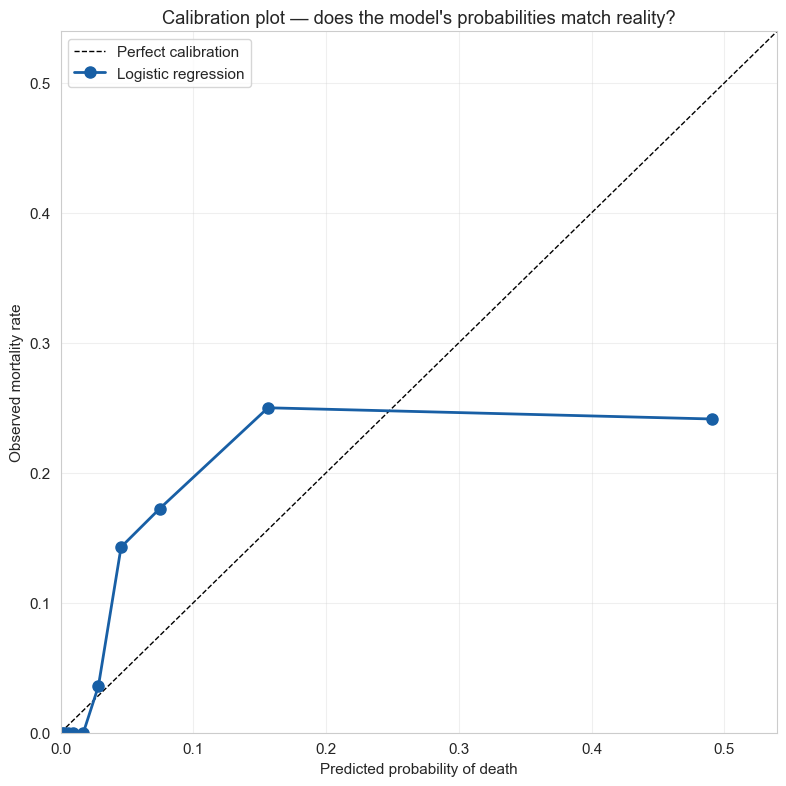


Calibration points:
Predicted    Observed    
0.001        0.000       
0.003        0.000       
0.005        0.000       
0.009        0.000       
0.017        0.000       
0.029        0.036       
0.046        0.143       
0.075        0.172       
0.156        0.250       
0.491        0.241       


In [6]:
# Compute calibration curve with 10 bins
prob_true, prob_pred = calibration_curve(y_test, y_pred_proba, n_bins=10, strategy="quantile")

fig, ax = plt.subplots(figsize=(8, 8))
ax.plot([0, 1], [0, 1], "k--", lw=1, label="Perfect calibration")
ax.plot(prob_pred, prob_true, "o-", color="#185FA5", lw=2, markersize=8, label="Logistic regression")
ax.set_xlabel("Predicted probability of death")
ax.set_ylabel("Observed mortality rate")
ax.set_title("Calibration plot — does the model's probabilities match reality?")
ax.legend(loc="upper left")
ax.grid(alpha=0.3)
ax.set_xlim(0, max(prob_pred.max(), prob_true.max()) * 1.1)
ax.set_ylim(0, max(prob_pred.max(), prob_true.max()) * 1.1)

plt.tight_layout()
plt.show()

# Print the points
print("\nCalibration points:")
print(f"{'Predicted':<12} {'Observed':<12}")
for p, o in zip(prob_pred, prob_true):
    print(f"{p:<12.3f} {o:<12.3f}")

## Confusion matrix at optimal threshold

Optimal threshold (Youden's J): 0.034
At this threshold:
  Sensitivity: 1.000
  Specificity: 0.640


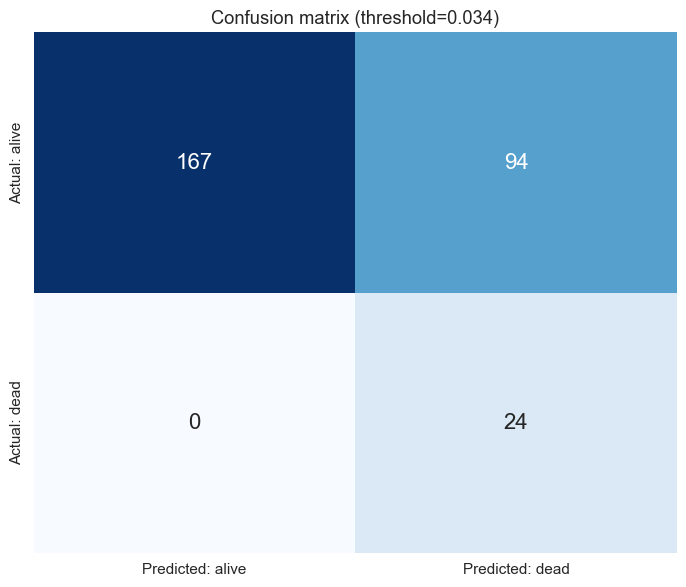


Classification report:
              precision    recall  f1-score   support

       alive       1.00      0.64      0.78       261
        dead       0.20      1.00      0.34        24

    accuracy                           0.67       285
   macro avg       0.60      0.82      0.56       285
weighted avg       0.93      0.67      0.74       285



In [8]:
# Compute J statistic across all thresholds and find optimum
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
youden_j = tpr - fpr
optimal_idx = np.argmax(youden_j)
optimal_threshold = thresholds[optimal_idx]

print(f"Optimal threshold (Youden's J): {optimal_threshold:.3f}")
print(f"At this threshold:")
print(f"  Sensitivity: {tpr[optimal_idx]:.3f}")
print(f"  Specificity: {1 - fpr[optimal_idx]:.3f}")

# Apply threshold and build confusion matrix
y_pred = (y_pred_proba >= optimal_threshold).astype(int)
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["Predicted: alive", "Predicted: dead"],
    yticklabels=["Actual: alive", "Actual: dead"],
    cbar=False, ax=ax, annot_kws={"size": 16},
)
ax.set_title(f"Confusion matrix (threshold={optimal_threshold:.3f})")
plt.tight_layout()
plt.show()

# Detailed classification report
print("\nClassification report:")
print(classification_report(y_test, y_pred, target_names=["alive", "dead"]))

## Save the trained model

In [10]:
os.makedirs("../models", exist_ok=True)
joblib.dump(pipeline, "../models/baseline_logistic_regression.pkl")

# Save predictions for the test set so we can compare with future models
test_predictions = pd.DataFrame({
    "patientunitstayid": features.iloc[X_test.index]["patientunitstayid"].values,
    "y_true": y_test.values,
    "y_pred_proba": y_pred_proba,
})
test_predictions.to_parquet("../data/predictions_baseline.parquet", index=False)

print(f"Saved trained pipeline to models/baseline_logistic_regression.pkl")
print(f"Saved test predictions to data/predictions_baseline.parquet")
print(f"\nFinal baseline performance:")
print(f"  ROC-AUC: {roc_auc:.3f}")
print(f"  PR-AUC:  {pr_auc:.3f}")
print(f"  Sensitivity at optimal threshold: {tpr[optimal_idx]:.3f}")
print(f"  Specificity at optimal threshold: {1 - fpr[optimal_idx]:.3f}")

Saved trained pipeline to models/baseline_logistic_regression.pkl
Saved test predictions to data/predictions_baseline.parquet

Final baseline performance:
  ROC-AUC: 0.845
  PR-AUC:  0.257
  Sensitivity at optimal threshold: 1.000
  Specificity at optimal threshold: 0.640


In [11]:
# Compare threshold strategies — 80% sensitivity vs Youden's J vs F1
from sklearn.metrics import f1_score, fbeta_score

# Find threshold for 80% sensitivity
fpr_curve, tpr_curve, thresholds_curve = roc_curve(y_test, y_pred_proba)
idx_80sens = np.argmin(np.abs(tpr_curve - 0.80))
threshold_80sens = thresholds_curve[idx_80sens]

# Find threshold maximizing F1
thresholds_test = np.linspace(0.01, 0.99, 100)
f1_scores = [f1_score(y_test, (y_pred_proba >= t).astype(int)) for t in thresholds_test]
threshold_f1 = thresholds_test[np.argmax(f1_scores)]

print(f"Threshold strategies for the baseline model:")
print(f"{'Strategy':<25} {'Threshold':<12} {'Sens':<8} {'Spec':<8} {'Precision':<12} {'F1':<8}")
print("-" * 75)
for name, threshold in [
    ("Youden's J (current)",   optimal_threshold),
    ("80% sensitivity target", threshold_80sens),
    ("Max F1",                 threshold_f1),
]:
    y_pred_t = (y_pred_proba >= threshold).astype(int)
    cm_t = confusion_matrix(y_test, y_pred_t)
    tn, fp, fn, tp = cm_t.ravel()
    sens = tp / (tp + fn) if (tp + fn) > 0 else 0
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0
    f1 = 2 * prec * sens / (prec + sens) if (prec + sens) > 0 else 0
    print(f"{name:<25} {threshold:<12.3f} {sens:<8.3f} {spec:<8.3f} {prec:<12.3f} {f1:<8.3f}")

Threshold strategies for the baseline model:
Strategy                  Threshold    Sens     Spec     Precision    F1      
---------------------------------------------------------------------------
Youden's J (current)      0.034        1.000    0.640    0.203        0.338   
80% sensitivity target    0.059        0.792    0.747    0.224        0.349   
Max F1                    0.050        0.917    0.716    0.229        0.367   


In [12]:
# Add this as a new cell to capture the threshold comparison results in the saved predictions
threshold_summary = pd.DataFrame({
    "strategy": ["Youden's J", "80% sensitivity", "Max F1"],
    "threshold": [optimal_threshold, threshold_80sens, threshold_f1],
})
threshold_summary.to_parquet("../data/baseline_thresholds.parquet", index=False)
print("Saved threshold summary.")

Saved threshold summary.
